In [1]:
import numpy as np
import matplotlib.pyplot as plt
# 陈梓欣

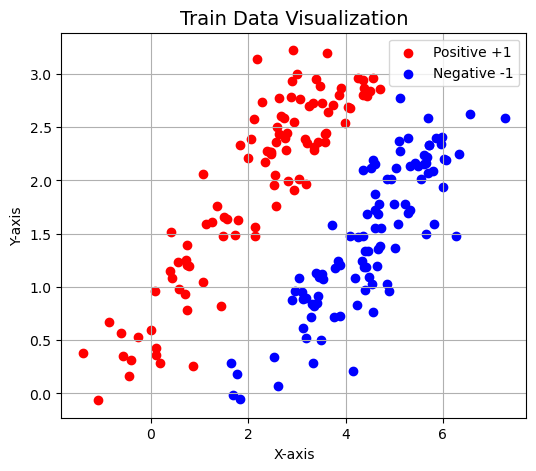

In [2]:
# 数据载入与划分
# datasetTo.txt 共600行：前200行为训练集，后400行为测试集
data = np.loadtxt("data/datasetTo.txt")

X_train = data[:200, :2]   # 训练数据的二维特征
y_train = data[:200, 2]    # 训练标签（1 或 -1）

X_test = data[200:, :2]    # 测试数据
y_test = data[200:, 2]     # 测试标签

## 设置中文字体与负号正常显示
# plt.rcParams['font.sans-serif'] = ['SimHei']   # 显示中文
# plt.rcParams['axes.unicode_minus'] = False     # 正常显示负号

# 显示训练数据的分布
plt.figure(figsize=(6, 5))
plt.title("Train Data Visualization", fontsize=14)
plt.scatter(X_train[y_train == 1][:, 0], X_train[y_train == 1][:, 1], c='r', label='Positive +1')
plt.scatter(X_train[y_train == -1][:, 0], X_train[y_train == -1][:, 1], c='b', label='Negative -1')
plt.legend()
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.grid(True)
plt.show()

In [16]:
# 感知机训练算法实现
def perceptron_train(X, y, eta=0.1, max_iter=1000):
    """
    感知机训练函数
    参数：
        X: 训练样本矩阵 (N, 2)
        y: 样本标签 (N,)
        eta: 学习率
        max_iter: 最大迭代次数
    返回：
        w, b: 训练得到的权重和偏置
    """
    n_samples, n_features = X.shape
    w = np.zeros(n_features)
    b = 0
    
    for epoch in range(max_iter):
        error_count = 0
        for i in range(n_samples):
            # 感知机判别函数
            if y[i] * (np.dot(w, X[i]) + b) <= 0:
                # 更新参数
                w += eta * y[i] * X[i]
                b += eta * y[i]
                error_count += 1
        if error_count == 0:
            break
    return w, b

In [17]:
# 测试与可视化
def plot_decision_boundary(X, y, w, b, title):
    plt.figure(figsize=(6, 5))
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], c='r', label='Positive +1')
    plt.scatter(X[y == -1][:, 0], X[y == -1][:, 1], c='b', label='Negative -1')
    
    # 决策平面（直线）：w1*x1 + w2*x2 + b = 0 → x2 = -(w1*x1 + b)/w2
    x1 = np.linspace(min(X[:,0]), max(X[:,0]), 100)
    x2 = -(w[0]*x1 + b)/w[1]
    plt.plot(x1, x2, 'k--', label='Separating Plane')
    
    plt.title(title)
    plt.legend()
    plt.xlabel("X-axis")
    plt.ylabel("Y-axis")
    plt.grid(True)
    plt.show()

学习率 η = 0.1 时:
  训练得到的权重 w = [-0.9854477   1.29727953]
  偏置 b = 1.100
  测试集分类准确率 = 98.50%



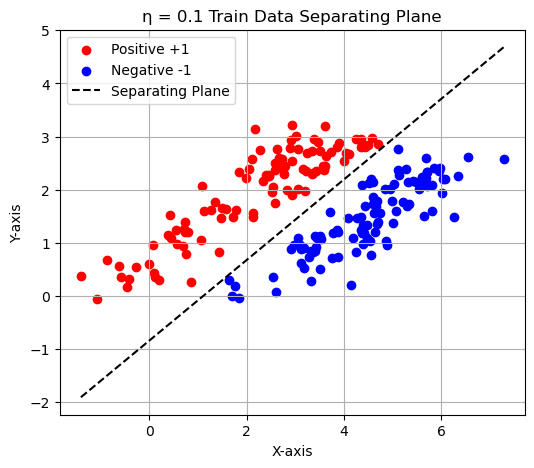

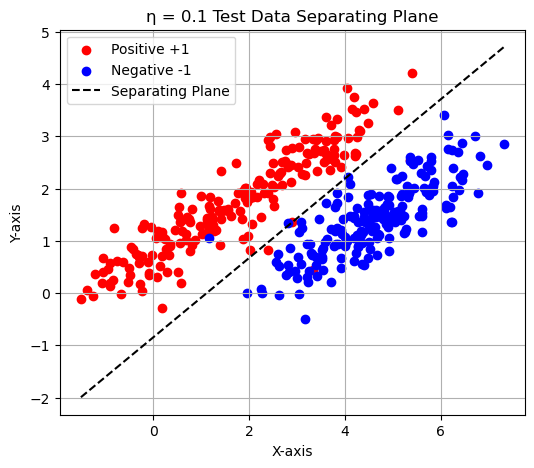

学习率 η = 0.3 时:
  训练得到的权重 w = [-2.95634309  3.89183859]
  偏置 b = 3.300
  测试集分类准确率 = 98.50%



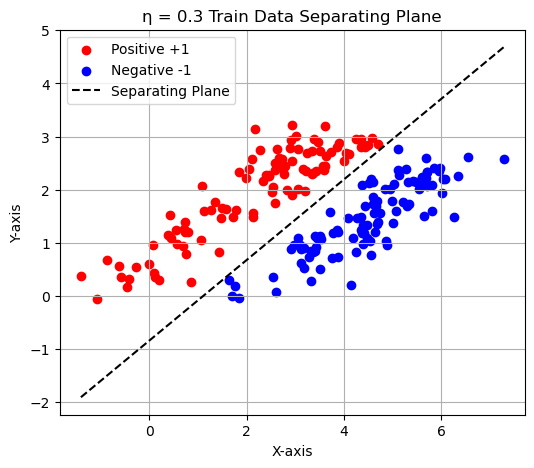

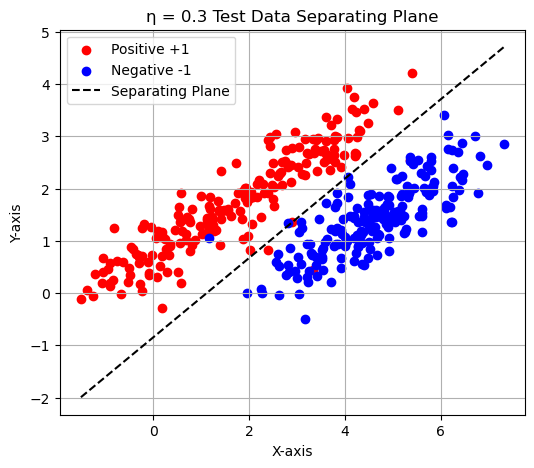

学习率 η = 0.5 时:
  训练得到的权重 w = [-4.92723848  6.48639765]
  偏置 b = 5.500
  测试集分类准确率 = 98.50%



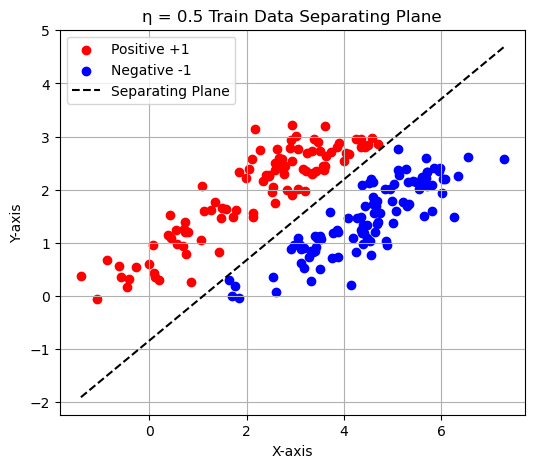

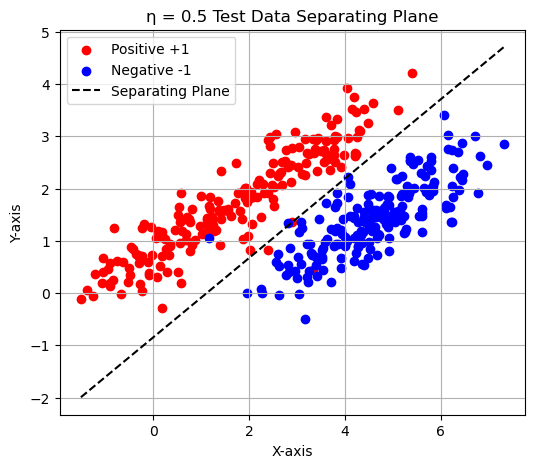

学习率 η = 0.7 时:
  训练得到的权重 w = [-6.89813387  9.0809567 ]
  偏置 b = 7.700
  测试集分类准确率 = 98.50%



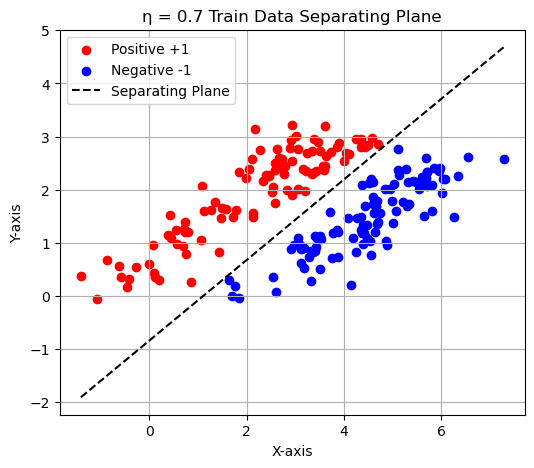

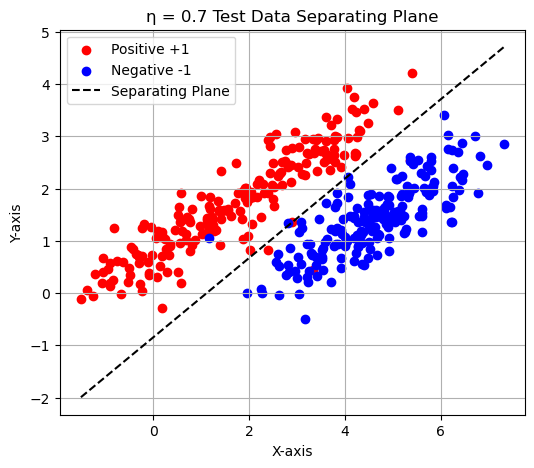

学习率 η = 0.9 时:
  训练得到的权重 w = [-8.86902926 11.67551576]
  偏置 b = 9.900
  测试集分类准确率 = 98.50%



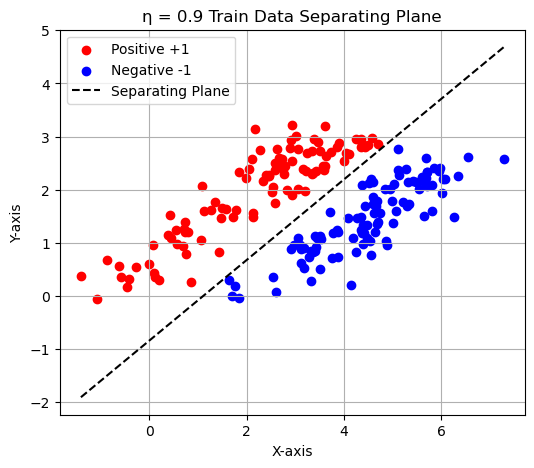

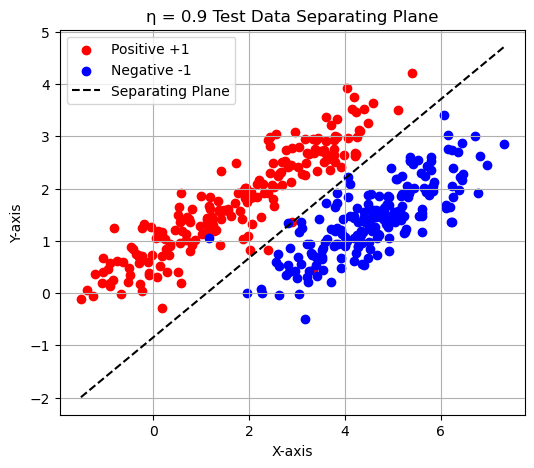

In [18]:
# 在不同学习率下训练与测试
etas = [0.1, 0.3, 0.5, 0.7, 0.9]
for eta in etas:
    w, b = perceptron_train(X_train, y_train, eta)
    
    # 对测试集进行分类预测
    y_pred = np.sign(np.dot(X_test, w) + b)
    accuracy = np.mean(y_pred == y_test)
    
    print(f"学习率 η = {eta:.1f} 时:")
    print(f"  训练得到的权重 w = {w}")
    print(f"  偏置 b = {b:.3f}")
    print(f"  测试集分类准确率 = {accuracy*100:.2f}%\n")
    
    plot_decision_boundary(X_train, y_train, w, b, title=f"η = {eta:.1f} Train Data Separating Plane")
    plot_decision_boundary(X_test, y_test, w, b, title=f"η = {eta:.1f} Test Data Separating Plane")


In [19]:
# 感知机训练算法实现（带打印）
def perceptron_train(X, y, eta=0.1, max_iter=1000):
    """
    感知机训练函数
    参数：
        X: 训练样本矩阵 (N, 2)
        y: 样本标签 (N,)
        eta: 学习率
        max_iter: 最大迭代次数
    返回：
        w, b: 训练得到的权重和偏置
    """
    n_samples, n_features = X.shape
    w = np.zeros(n_features)
    b = 0
    
    print(f"\n--- 开始训练 (η = {eta}) ---")
    print(f"初始参数：w = {w}, b = {b}\n")

    for epoch in range(max_iter):
        error_count = 0
        for i in range(n_samples):
            # 感知机判别函数
            if y[i] * (np.dot(w, X[i]) + b) <= 0:
                # 更新参数
                w += eta * y[i] * X[i]
                b += eta * y[i]
                error_count += 1
                print(f"第 {epoch+1} 轮，第 {i+1} 个样本被误分类 → 更新后 w = {w}, b = {b:.3f}")

        # 若一轮中没有误分类，说明已收敛
        if error_count == 0:
            print(f"\n模型在第 {epoch+1} 轮迭代后收敛！")
            break
        else:
            print(f"第 {epoch+1} 轮结束，误分类样本数 = {error_count}\n")

    print(f"最终参数：w = {w}, b = {b:.3f}\n")
    return w, b

In [45]:
# 测试与可视化
def plot_decision_boundary(X, y, w, b, title):
    plt.figure(figsize=(6, 5))
    plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], c='r', label='Positive +1')
    plt.scatter(X[y == -1][:, 0], X[y == -1][:, 1], c='b', label='Negative -1')
    
    # 决策平面（直线）：w1*x1 + w2*x2 + b = 0 → x2 = -(w1*x1 + b)/w2
    x1 = np.linspace(min(X[:,0]), max(X[:,0]), 100)
    x2 = -(w[0]*x1 + b)/w[1]
    plt.plot(x1, x2, 'k--', label='Separating Plane')
    
    plt.title(title)
    plt.legend()
    plt.xlabel("X-axis")
    plt.ylabel("Y-axis")
    plt.grid(True)
    plt.show()


--- 开始训练 (η = 0.1) ---
初始参数：w = [0. 0.], b = 0

第 1 轮，第 1 个样本被误分类 → 更新后 w = [0.07358352 0.1206051 ], b = 0.100
第 1 轮，第 101 个样本被误分类 → 更新后 w = [-0.65441928 -0.13784022], b = 0.000
第 1 轮结束，误分类样本数 = 2

第 2 轮，第 1 个样本被误分类 → 更新后 w = [-0.58083576 -0.01723512], b = 0.100
第 2 轮，第 2 个样本被误分类 → 更新后 w = [-0.50878766  0.10833093], b = 0.200
第 2 轮，第 3 个样本被误分类 → 更新后 w = [-0.3962833   0.26740366], b = 0.300
第 2 轮，第 20 个样本被误分类 → 更新后 w = [-0.25300499  0.34958304], b = 0.400
第 2 轮，第 111 个样本被误分类 → 更新后 w = [-0.68978957  0.14007812], b = 0.300
第 2 轮结束，误分类样本数 = 5

第 3 轮，第 1 个样本被误分类 → 更新后 w = [-0.61620605  0.26068322], b = 0.400
第 3 轮，第 12 个样本被误分类 → 更新后 w = [-0.46630409  0.42604738], b = 0.500
第 3 轮，第 32 个样本被误分类 → 更新后 w = [-0.04058351  0.72178813], b = 0.600
第 3 轮，第 101 个样本被误分类 → 更新后 w = [-0.76858631  0.46334281], b = 0.500
第 3 轮结束，误分类样本数 = 4

第 4 轮，第 20 个样本被误分类 → 更新后 w = [-0.62530801  0.54552219], b = 0.600
第 4 轮，第 32 个样本被误分类 → 更新后 w = [-0.19958743  0.84126293], b = 0.700
第 4 轮，第 101 个样本被误分类 → 更新后 w = [-0.927

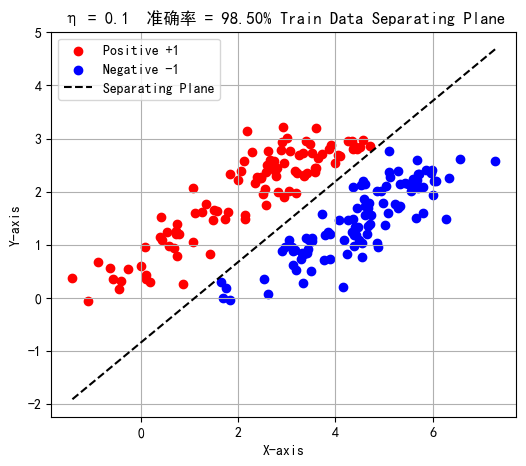

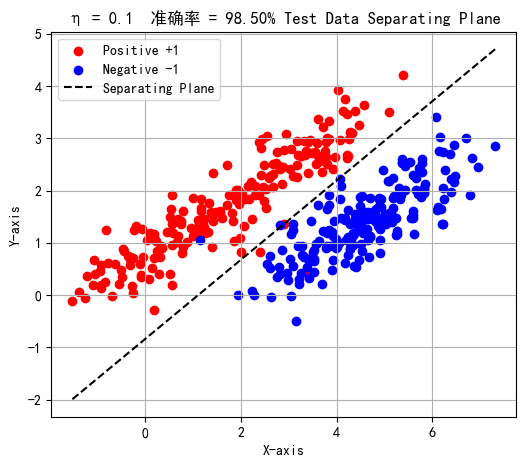


--- 开始训练 (η = 0.2) ---
初始参数：w = [0. 0.], b = 0

第 1 轮，第 1 个样本被误分类 → 更新后 w = [0.14716703 0.24121019], b = 0.200
第 1 轮，第 101 个样本被误分类 → 更新后 w = [-1.30883856 -0.27568044], b = 0.000
第 1 轮结束，误分类样本数 = 2

第 2 轮，第 1 个样本被误分类 → 更新后 w = [-1.16167153 -0.03447025], b = 0.200
第 2 轮，第 2 个样本被误分类 → 更新后 w = [-1.01757532  0.21666186], b = 0.400
第 2 轮，第 3 个样本被误分类 → 更新后 w = [-0.79256659  0.53480732], b = 0.600
第 2 轮，第 20 个样本被误分类 → 更新后 w = [-0.50600998  0.69916608], b = 0.800
第 2 轮，第 111 个样本被误分类 → 更新后 w = [-1.37957914  0.28015624], b = 0.600
第 2 轮结束，误分类样本数 = 5

第 3 轮，第 1 个样本被误分类 → 更新后 w = [-1.23241211  0.52136643], b = 0.800
第 3 轮，第 12 个样本被误分类 → 更新后 w = [-0.93260817  0.85209477], b = 1.000
第 3 轮，第 32 个样本被误分类 → 更新后 w = [-0.08116703  1.44357625], b = 1.200
第 3 轮，第 101 个样本被误分类 → 更新后 w = [-1.53717262  0.92668562], b = 1.000
第 3 轮结束，误分类样本数 = 4

第 4 轮，第 20 个样本被误分类 → 更新后 w = [-1.25061601  1.09104438], b = 1.200
第 4 轮，第 32 个样本被误分类 → 更新后 w = [-0.39917487  1.68252587], b = 1.400
第 4 轮，第 101 个样本被误分类 → 更新后 w = [-1.855

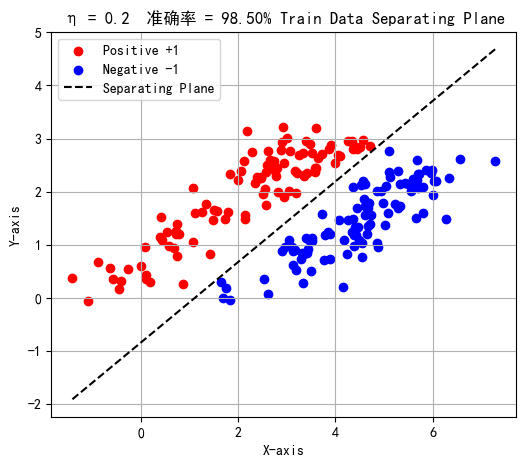

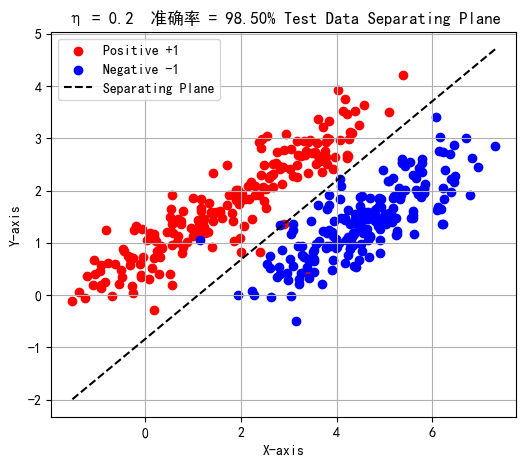


--- 开始训练 (η = 0.3) ---
初始参数：w = [0. 0.], b = 0

第 1 轮，第 1 个样本被误分类 → 更新后 w = [0.22075055 0.36181529], b = 0.300
第 1 轮，第 101 个样本被误分类 → 更新后 w = [-1.96325784 -0.41352066], b = 0.000
第 1 轮结束，误分类样本数 = 2

第 2 轮，第 1 个样本被误分类 → 更新后 w = [-1.74250729 -0.05170537], b = 0.300
第 2 轮，第 2 个样本被误分类 → 更新后 w = [-1.52636297  0.32499279], b = 0.600
第 2 轮，第 3 个样本被误分类 → 更新后 w = [-1.18884989  0.80221098], b = 0.900
第 2 轮，第 20 个样本被误分类 → 更新后 w = [-0.75901498  1.04874912], b = 1.200
第 2 轮，第 111 个样本被误分类 → 更新后 w = [-2.06936871  0.42023436], b = 0.900
第 2 轮结束，误分类样本数 = 5

第 3 轮，第 1 个样本被误分类 → 更新后 w = [-1.84861816  0.78204965], b = 1.200
第 3 轮，第 12 个样本被误分类 → 更新后 w = [-1.39891226  1.27814215], b = 1.500
第 3 轮，第 32 个样本被误分类 → 更新后 w = [-0.12175054  2.16536438], b = 1.800
第 3 轮，第 101 个样本被误分类 → 更新后 w = [-2.30575893  1.39002843], b = 1.500
第 3 轮结束，误分类样本数 = 4

第 4 轮，第 20 个样本被误分类 → 更新后 w = [-1.87592402  1.63656657], b = 1.800
第 4 轮，第 32 个样本被误分类 → 更新后 w = [-0.5987623  2.5237888], b = 2.100
第 4 轮，第 101 个样本被误分类 → 更新后 w = [-2.78277

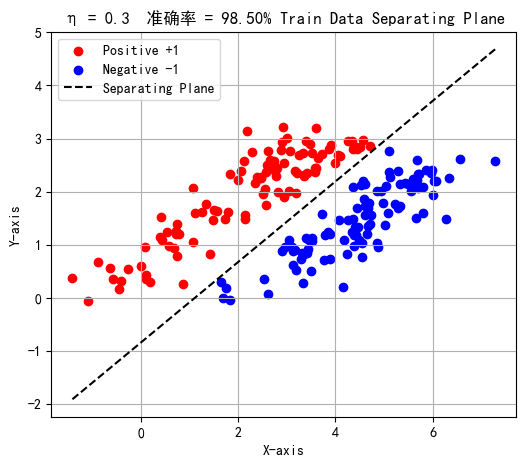

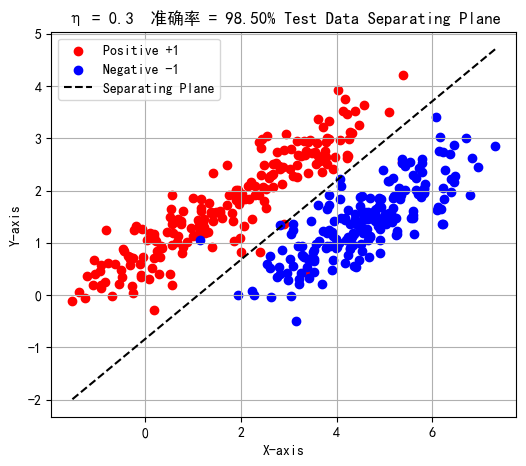


--- 开始训练 (η = 0.4) ---
初始参数：w = [0. 0.], b = 0

第 1 轮，第 1 个样本被误分类 → 更新后 w = [0.29433407 0.48242039], b = 0.400
第 1 轮，第 101 个样本被误分类 → 更新后 w = [-2.61767712 -0.55136088], b = 0.000
第 1 轮结束，误分类样本数 = 2

第 2 轮，第 1 个样本被误分类 → 更新后 w = [-2.32334305 -0.06894049], b = 0.400
第 2 轮，第 2 个样本被误分类 → 更新后 w = [-2.03515063  0.43332372], b = 0.800
第 2 轮，第 3 个样本被误分类 → 更新后 w = [-1.58513318  1.06961464], b = 1.200
第 2 轮，第 20 个样本被误分类 → 更新后 w = [-1.01201997  1.39833216], b = 1.600
第 2 轮，第 111 个样本被误分类 → 更新后 w = [-2.75915828  0.56031248], b = 1.200
第 2 轮结束，误分类样本数 = 5

第 3 轮，第 1 个样本被误分类 → 更新后 w = [-2.46482421  1.04273286], b = 1.600
第 3 轮，第 12 个样本被误分类 → 更新后 w = [-1.86521634  1.70418953], b = 2.000
第 3 轮，第 32 个样本被误分类 → 更新后 w = [-0.16233405  2.88715251], b = 2.400
第 3 轮，第 101 个样本被误分类 → 更新后 w = [-3.07434524  1.85337124], b = 2.000
第 3 轮结束，误分类样本数 = 4

第 4 轮，第 20 个样本被误分类 → 更新后 w = [-2.50123203  2.18208876], b = 2.400
第 4 轮，第 32 个样本被误分类 → 更新后 w = [-0.79834974  3.36505173], b = 2.800
第 4 轮，第 101 个样本被误分类 → 更新后 w = [-3.710

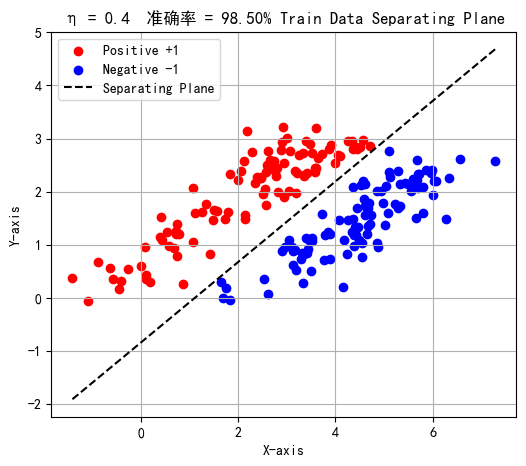

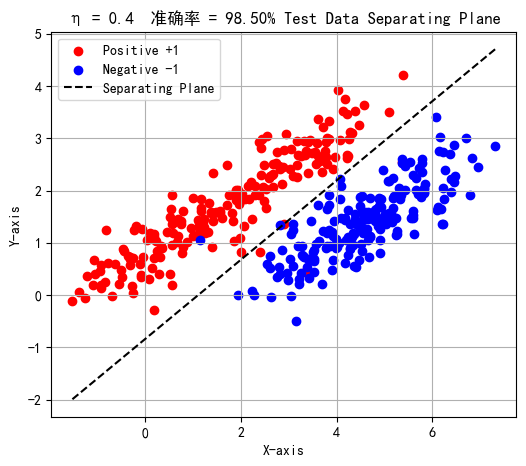


--- 开始训练 (η = 0.5) ---
初始参数：w = [0. 0.], b = 0

第 1 轮，第 1 个样本被误分类 → 更新后 w = [0.36791758 0.60302549], b = 0.500
第 1 轮，第 101 个样本被误分类 → 更新后 w = [-3.2720964 -0.6892011], b = 0.000
第 1 轮结束，误分类样本数 = 2

第 2 轮，第 1 个样本被误分类 → 更新后 w = [-2.90417881 -0.08617562], b = 0.500
第 2 轮，第 2 个样本被误分类 → 更新后 w = [-2.54393829  0.54165465], b = 1.000
第 2 轮，第 3 个样本被误分类 → 更新后 w = [-1.98141648  1.3370183 ], b = 1.500
第 2 轮，第 20 个样本被误分类 → 更新后 w = [-1.26502496  1.7479152 ], b = 2.000
第 2 轮，第 111 个样本被误分类 → 更新后 w = [-3.44894785  0.70039059], b = 1.500
第 2 轮结束，误分类样本数 = 5

第 3 轮，第 1 个样本被误分类 → 更新后 w = [-3.08103027  1.30341608], b = 2.000
第 3 轮，第 12 个样本被误分类 → 更新后 w = [-2.33152043  2.13023692], b = 2.500
第 3 轮，第 32 个样本被误分类 → 更新后 w = [-0.20291757  3.60894063], b = 3.000
第 3 轮，第 101 个样本被误分类 → 更新后 w = [-3.84293155  2.31671405], b = 2.500
第 3 轮结束，误分类样本数 = 4

第 4 轮，第 20 个样本被误分类 → 更新后 w = [-3.12654003  2.72761095], b = 3.000
第 4 轮，第 32 个样本被误分类 → 更新后 w = [-0.99793717  4.20631467], b = 3.500
第 4 轮，第 101 个样本被误分类 → 更新后 w = [-4.63795

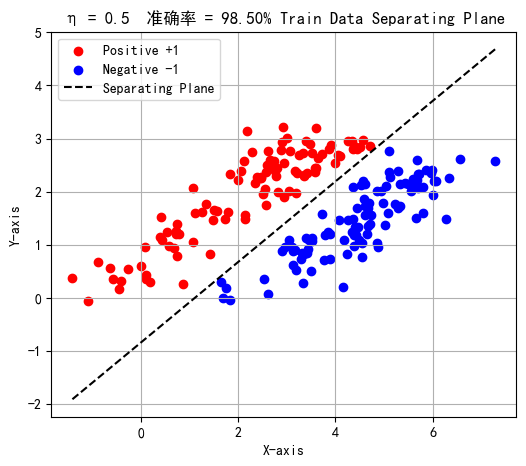

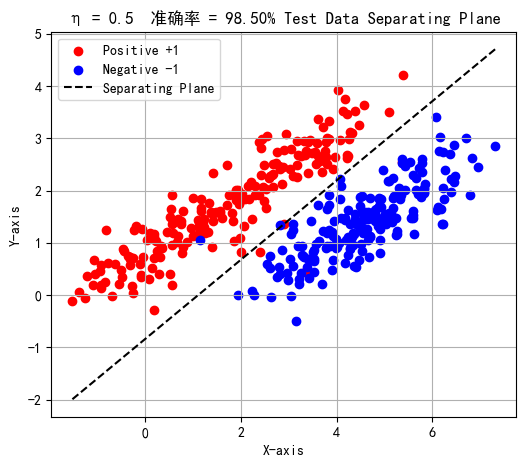


--- 开始训练 (η = 0.6) ---
初始参数：w = [0. 0.], b = 0

第 1 轮，第 1 个样本被误分类 → 更新后 w = [0.4415011  0.72363058], b = 0.600
第 1 轮，第 101 个样本被误分类 → 更新后 w = [-3.92651568 -0.82704132], b = 0.000
第 1 轮结束，误分类样本数 = 2

第 2 轮，第 1 个样本被误分类 → 更新后 w = [-3.48501458 -0.10341074], b = 0.600
第 2 轮，第 2 个样本被误分类 → 更新后 w = [-3.05272595  0.64998558], b = 1.200
第 2 轮，第 3 个样本被误分类 → 更新后 w = [-2.37769978  1.60442196], b = 1.800
第 2 轮，第 20 个样本被误分类 → 更新后 w = [-1.51802995  2.09749824], b = 2.400
第 2 轮，第 111 个样本被误分类 → 更新后 w = [-4.13873742  0.84046871], b = 1.800
第 2 轮结束，误分类样本数 = 5

第 3 轮，第 1 个样本被误分类 → 更新后 w = [-3.69723632  1.5640993 ], b = 2.400
第 3 轮，第 12 个样本被误分类 → 更新后 w = [-2.79782451  2.5562843 ], b = 3.000
第 3 轮，第 32 个样本被误分类 → 更新后 w = [-0.24350108  4.33072876], b = 3.600
第 3 轮，第 101 个样本被误分类 → 更新后 w = [-4.61151786  2.78005686], b = 3.000
第 3 轮结束，误分类样本数 = 4

第 4 轮，第 20 个样本被误分类 → 更新后 w = [-3.75184804  3.27313314], b = 3.600
第 4 轮，第 32 个样本被误分类 → 更新后 w = [-1.19752461  5.0475776 ], b = 4.200
第 4 轮，第 101 个样本被误分类 → 更新后 w = [-5.565

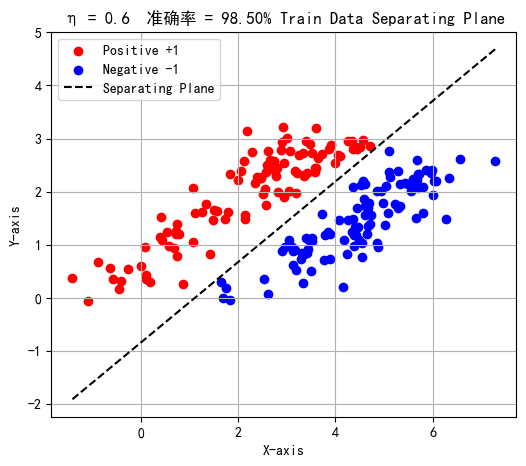

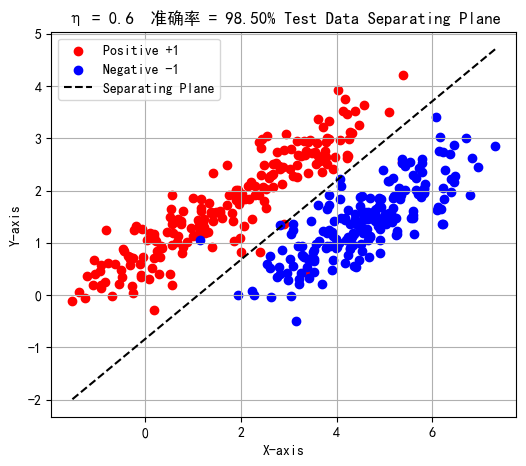


--- 开始训练 (η = 0.7) ---
初始参数：w = [0. 0.], b = 0

第 1 轮，第 1 个样本被误分类 → 更新后 w = [0.51508462 0.84423568], b = 0.700
第 1 轮，第 101 个样本被误分类 → 更新后 w = [-4.58093496 -0.96488154], b = 0.000
第 1 轮结束，误分类样本数 = 2

第 2 轮，第 1 个样本被误分类 → 更新后 w = [-4.06585034 -0.12064586], b = 0.700
第 2 轮，第 2 个样本被误分类 → 更新后 w = [-3.56151361  0.75831651], b = 1.400
第 2 轮，第 3 个样本被误分类 → 更新后 w = [-2.77398307  1.87182562], b = 2.100
第 2 轮，第 20 个样本被误分类 → 更新后 w = [-1.77103495  2.44708128], b = 2.800
第 2 轮，第 111 个样本被误分类 → 更新后 w = [-4.82852699  0.98054683], b = 2.100
第 2 轮结束，误分类样本数 = 5

第 3 轮，第 1 个样本被误分类 → 更新后 w = [-4.31344238  1.82478251], b = 2.800
第 3 轮，第 12 个样本被误分类 → 更新后 w = [-3.2641286   2.98233168], b = 3.500
第 3 轮，第 32 个样本被误分类 → 更新后 w = [-0.28408459  5.05251689], b = 4.200
第 3 轮，第 101 个样本被误分类 → 更新后 w = [-5.38010417  3.24339967], b = 3.500
第 3 轮结束，误分类样本数 = 4

第 4 轮，第 20 个样本被误分类 → 更新后 w = [-4.37715605  3.81865532], b = 4.200
第 4 轮，第 32 个样本被误分类 → 更新后 w = [-1.39711204  5.88884053], b = 4.900
第 4 轮，第 101 个样本被误分类 → 更新后 w = [-6.493

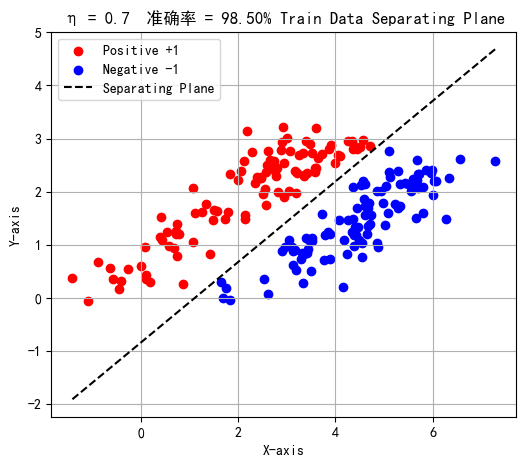

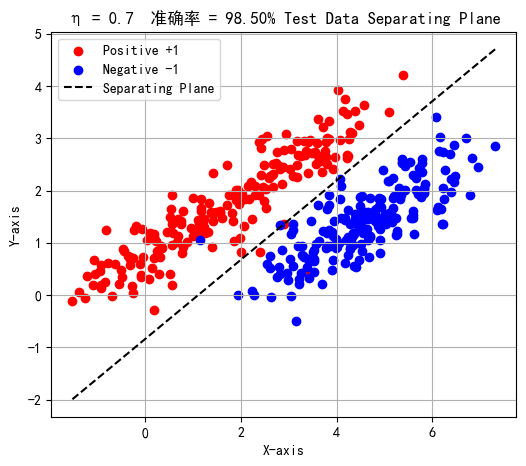


--- 开始训练 (η = 0.8) ---
初始参数：w = [0. 0.], b = 0

第 1 轮，第 1 个样本被误分类 → 更新后 w = [0.58866814 0.96484078], b = 0.800
第 1 轮，第 101 个样本被误分类 → 更新后 w = [-5.23535424 -1.10272176], b = 0.000
第 1 轮结束，误分类样本数 = 2

第 2 轮，第 1 个样本被误分类 → 更新后 w = [-4.6466861  -0.13788099], b = 0.800
第 2 轮，第 2 个样本被误分类 → 更新后 w = [-4.07030126  0.86664744], b = 1.600
第 2 轮，第 3 个样本被误分类 → 更新后 w = [-3.17026637  2.13922928], b = 2.400
第 2 轮，第 20 个样本被误分类 → 更新后 w = [-2.02403994  2.79666432], b = 3.200
第 2 轮，第 111 个样本被误分类 → 更新后 w = [-5.51831657  1.12062495], b = 2.400
第 2 轮结束，误分类样本数 = 5

第 3 轮，第 1 个样本被误分类 → 更新后 w = [-4.92964843  2.08546573], b = 3.200
第 3 轮，第 12 个样本被误分类 → 更新后 w = [-3.73043268  3.40837906], b = 4.000
第 3 轮，第 32 个样本被误分类 → 更新后 w = [-0.32466811  5.77430502], b = 4.800
第 3 轮，第 101 个样本被误分类 → 更新后 w = [-6.14869048  3.70674248], b = 4.000
第 3 轮结束，误分类样本数 = 4

第 4 轮，第 20 个样本被误分类 → 更新后 w = [-5.00246406  4.36417751], b = 4.800
第 4 轮，第 32 个样本被误分类 → 更新后 w = [-1.59669948  6.73010346], b = 5.600
第 4 轮，第 101 个样本被误分类 → 更新后 w = [-7.420

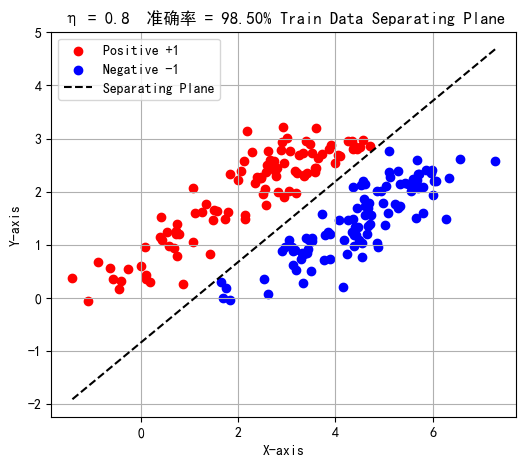

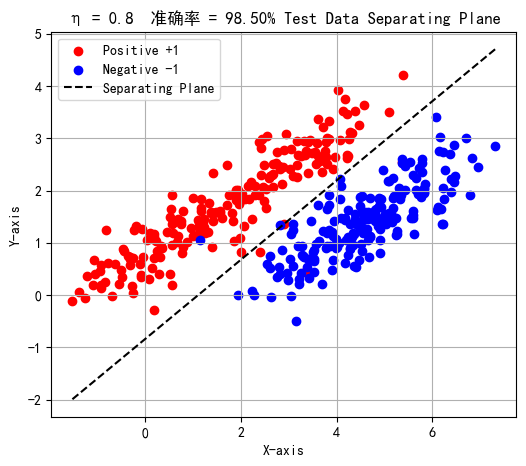


--- 开始训练 (η = 0.9) ---
初始参数：w = [0. 0.], b = 0

第 1 轮，第 1 个样本被误分类 → 更新后 w = [0.66225165 1.08544587], b = 0.900
第 1 轮，第 101 个样本被误分类 → 更新后 w = [-5.88977352 -1.24056198], b = 0.000
第 1 轮结束，误分类样本数 = 2

第 2 轮，第 1 个样本被误分类 → 更新后 w = [-5.22752187 -0.15511611], b = 0.900
第 2 轮，第 2 个样本被误分类 → 更新后 w = [-4.57908892  0.97497837], b = 1.800
第 2 轮，第 3 个样本被误分类 → 更新后 w = [-3.56654966  2.40663294], b = 2.700
第 2 轮，第 20 个样本被误分类 → 更新后 w = [-2.27704493  3.14624736], b = 3.600
第 2 轮，第 111 个样本被误分类 → 更新后 w = [-6.20810614  1.26070307], b = 2.700
第 2 轮结束，误分类样本数 = 5

第 3 轮，第 1 个样本被误分类 → 更新后 w = [-5.54585448  2.34614894], b = 3.600
第 3 轮，第 12 个样本被误分类 → 更新后 w = [-4.19673677  3.83442645], b = 4.500
第 3 轮，第 32 个样本被误分类 → 更新后 w = [-0.36525162  6.49609314], b = 5.400
第 3 轮，第 101 个样本被误分类 → 更新后 w = [-6.91727679  4.17008529], b = 4.500
第 3 轮结束，误分类样本数 = 4

第 4 轮，第 20 个样本被误分类 → 更新后 w = [-5.62777206  4.9096997 ], b = 5.400
第 4 轮，第 32 个样本被误分类 → 更新后 w = [-1.79628691  7.5713664 ], b = 6.300
第 4 轮，第 101 个样本被误分类 → 更新后 w = [-8.348

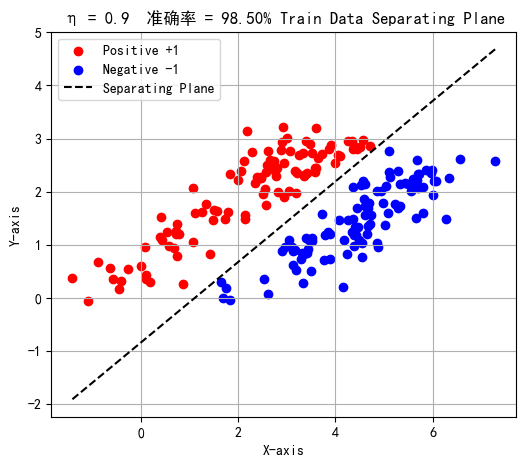

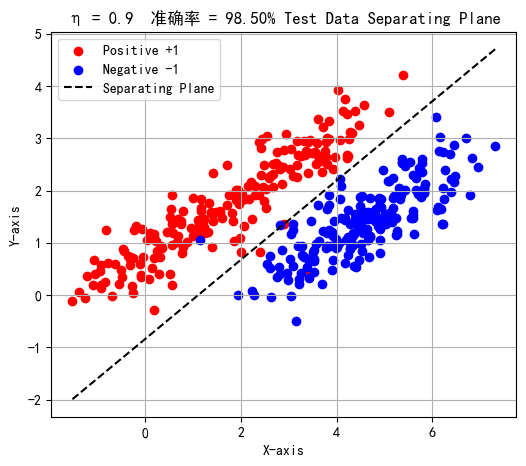

In [46]:
# 在不同学习率下训练与测试
etas = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
for eta in etas:
    w, b = perceptron_train(X_train, y_train, eta)
    
    # 对测试集进行分类预测
    y_pred = np.sign(np.dot(X_test, w) + b)
    accuracy = np.mean(y_pred == y_test)
    
    print(f"学习率 η = {eta:.1f} 时:")
    print(f"  训练得到的权重 w = {w}")
    print(f"  偏置 b = {b:.3f}")
    print(f"  测试集分类准确率 = {accuracy*100:.2f}%\n")
    
    plot_decision_boundary(X_train, y_train, w, b, title=f"η = {eta:.1f}  准确率 = {acc*100:.2f}% Train Data Separating Plane")
    plot_decision_boundary(X_test, y_test, w, b, title=f"η = {eta:.1f}  准确率 = {acc*100:.2f}% Test Data Separating Plane")


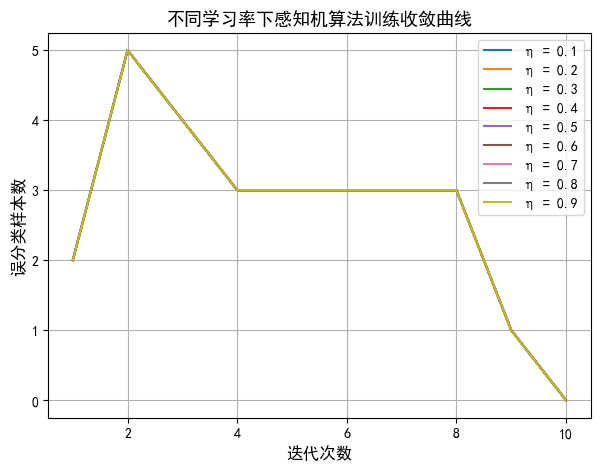

In [42]:
# 不同学习率下感知机算法训练收敛曲线
# 设置中文字体与负号正常显示
plt.rcParams['font.sans-serif'] = ['SimHei']   # 显示中文
plt.rcParams['axes.unicode_minus'] = False     # 正常显示负号

def perceptron_train_with_error(X, y, eta=0.1, max_iter=1000):
    """记录每轮误分类样本数量"""
    n_samples, n_features = X.shape
    w = np.zeros(n_features)
    b = 0
    errors = []  # 存储每轮误分类样本数
    
    for epoch in range(max_iter):
        error_count = 0
        for i in range(n_samples):
            if y[i] * (np.dot(w, X[i]) + b) <= 0:
                w += eta * y[i] * X[i]
                b += eta * y[i]
                error_count += 1
        errors.append(error_count)
        if error_count == 0:
            break
    return w, b, errors


# 绘制不同学习率下的误分类曲线
etas = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
plt.figure(figsize=(7, 5))

for eta in etas:
    _, _, errors = perceptron_train_with_error(X_train, y_train, eta)
    plt.plot(range(1, len(errors) + 1), errors, label=f"η = {eta}")

plt.title("不同学习率下感知机算法训练收敛曲线", fontsize=13)
plt.xlabel("迭代次数", fontsize=12)
plt.ylabel("误分类样本数", fontsize=12)
plt.legend()
plt.grid(True)
plt.show()


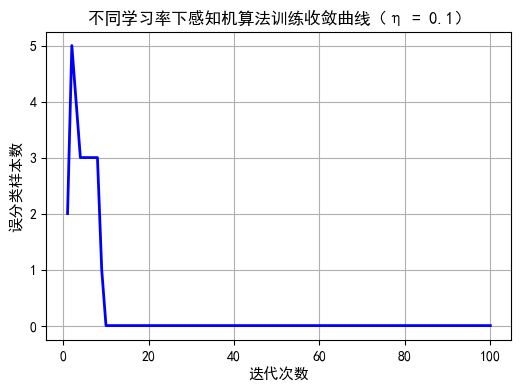

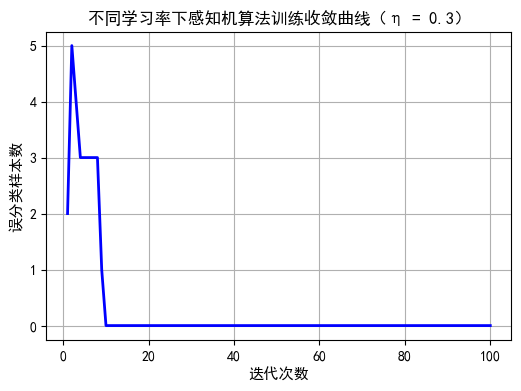

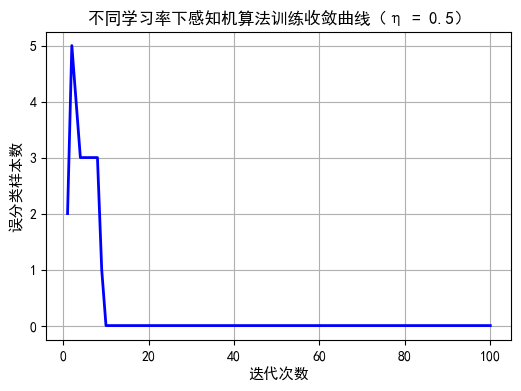

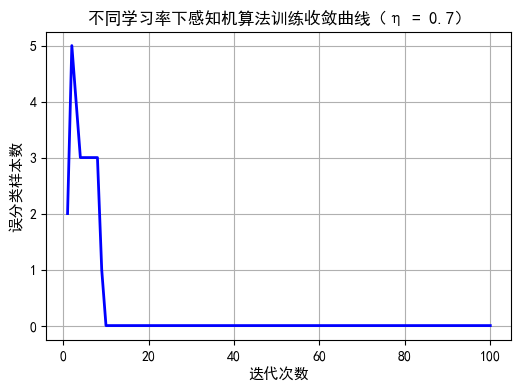

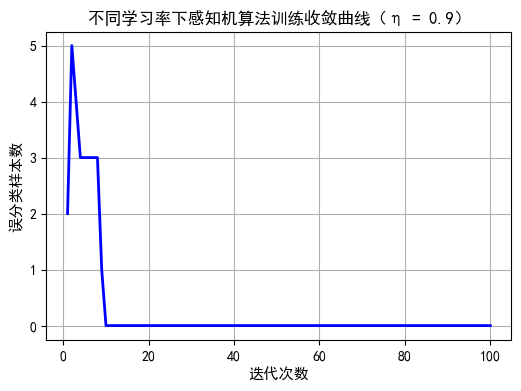

In [41]:
# 不同学习率下感知机算法训练收敛曲线
# 设置中文字体与负号正常显示
plt.rcParams['font.sans-serif'] = ['SimHei']   # 显示中文
plt.rcParams['axes.unicode_minus'] = False     # 正常显示负号


def perceptron_train_with_error(X, y, eta=0.1, max_iter=100):
    """记录每轮误分类样本数量"""
    n_samples, n_features = X.shape
    w = np.zeros(n_features)
    b = 0
    errors = []

    for epoch in range(max_iter):
        error_count = 0
        for i in range(n_samples):
            if y[i] * (np.dot(w, X[i]) + b) <= 0:
                w += eta * y[i] * X[i]
                b += eta * y[i]
                error_count += 1
        errors.append(error_count)
        # 为了绘制曲线，不提前终止收敛过程
    return w, b, errors


# 设置学习率列表
etas = [0.1, 0.3, 0.5, 0.7, 0.9]

# 分别绘制每个η对应的误分类曲线
for eta in etas:
    _, _, errors = perceptron_train_with_error(X_train, y_train, eta)
    plt.figure(figsize=(6, 4))
    plt.plot(range(1, len(errors) + 1), errors, color='b', linewidth=2)
    plt.title(f"不同学习率下感知机算法训练收敛曲线（η = {eta}）", fontsize=12)
    plt.xlabel("迭代次数", fontsize=11)
    plt.ylabel("误分类样本数", fontsize=11)
    plt.grid(True)
    plt.show()
